In [1]:
import os
import pickle
import logging

import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import numpyro
import numpyro.distributions as dist
from numpyro.diagnostics import hpdi

from hbmep.config import Config
from hbmep.model.utils import Site as site

from hbmep_paper.utils import setup_logging
from models import HierarchicalBayesianModel
from constants import (
    DATA_PATH,
    TOML_PATH,
    INFERENCE_FILE,
    NETCODE_FILE,
    BUILD_DIR,
    BOOTSTRAP_EXPERIMENTS_DIR
)

logger = logging.getLogger(__name__)
plt.rcParams["svg.fonttype"] = "none"

setup_logging(dir=BUILD_DIR, fname="figure")

NUM_SAMPLES = 5000
# NUM_SAMPLES = 100


Jan-06-2025 02:15:30 PM - hbmep_paper.utils.utils - INFO - Logging to /home/vishu/repos/hbmep-paper/reports/intraoperative/figure.log


In [2]:
# Load posterior
src = "/home/vishu/repos/hbmep-paper/reports/intraoperative/hierarchical_bayesian_model_20000W_20000S_4C_20T_20D_0.95A/inference.pkl"
with open(src, "rb") as f:
    model, mcmc, posterior_samples_ = pickle.load(f)

posterior_samples = posterior_samples_.copy()
if site.outlier_prob in posterior_samples:
    posterior_samples[site.outlier_prob] = 0 * posterior_samples[site.outlier_prob]

# Load data
df = pd.read_csv(DATA_PATH)
ind = ~df[model.response].isna().values.any(axis=-1)
df = df[ind].reset_index(drop=True).copy()
df, encoder_dict = model.load(df=df)


Jan-06-2025 02:15:30 PM - jax._src.xla_bridge - INFO - Unable to initialize backend 'cuda': 
Jan-06-2025 02:15:30 PM - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
Jan-06-2025 02:15:30 PM - jax._src.xla_bridge - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
Jan-06-2025 02:15:30 PM - jax._src.xla_bridge - WARNING - An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Jan-06-2025 02:15:31 PM - hbmep.dataset.core - INFO - Artefacts will be stored here - /home/vishu/repos/hbmep-paper/reports/intraoperative/hierarchical_bayesian_model_20000W_20000S_4C_20T_20D_0.95A
Jan-06-2025 02:15:31 PM - hbmep.dataset.core - INFO - Processing data ...
Jan-06-2025 02:15:31 PM - hbmep.utils.utils - INFO - func:load took: 0.00 sec


In [3]:
t = df.groupby(by=model.features)[model.intensity].nunique().values
print(t.mean())
print(t.std())


16.73076923076923
8.267441666923109


In [4]:
a_delta_loc = posterior_samples["a_delta_loc"]
(posterior_samples["a_delta_loc"] > 0).mean(axis=0)


array([[0.99775, 0.99975, 0.998  , 0.96625]])

In [5]:
subset = [(7, 0), (7, 1), (12, 0), (12, 1)]
ind = df[model.features].apply(tuple, axis=1).isin(subset)
df = df[ind].reset_index(drop=True).copy()

prediction_df = model.make_prediction_dataset(df=df, num_points=NUM_SAMPLES)
posterior_predictive = model.predict(df=prediction_df, posterior_samples=posterior_samples)


Jan-06-2025 02:15:31 PM - hbmep.utils.utils - INFO - func:make_prediction_dataset took: 0.00 sec
Jan-06-2025 02:17:30 PM - hbmep.utils.utils - INFO - func:predict took: 1 min and 58.77 sec


In [6]:
a = posterior_samples[site.a]
a_map = a.mean(axis=0)

mu = posterior_predictive[site.mu]
obs = posterior_predictive[site.obs]
obs_hpdi = hpdi(obs, prob=.95)

a_delta_loc = posterior_samples["a_delta_loc"]
a_delta_loc[:, 0, :].shape


(4000, 4)

In [7]:
CORRECTED_LEVEL = 1 - (0.05 / 4)
hdi = hpdi(a_delta_loc[:, 0, :], prob=CORRECTED_LEVEL).T
hdi


array([[ 0.50560328,  4.50841232],
       [ 0.99280627,  4.77010505],
       [ 0.45935978,  4.6739943 ],
       [-0.82665569,  4.53331129]])

In [8]:
# Plot aesthetics
response_colors = {
    # Lateral (light)
    0: {
        1: (0.6706, 0.8510, 0.9137),
        0: (0.8745, 0.7608, 0.4902),
        2: (0.9451, 0.7137, 0.8549),
        3: (0.7216, 0.8824, 0.5255)
    },
    # Midline (dark)
    1: {
        1: (0.1725, 0.4824, 0.7137),
        0: (0.6510, 0.3804, 0.1020),
        2: (0.8157, 0.1098, 0.5451),
        3: (0.3020, 0.6745, 0.1490)
    }
}
prior_color = (.7, .7, .7)
cmap = sns.color_palette("tab10")
axis_label_size = 10


In [9]:
from bootstrap__models import (
    DefaultHierarchicalBayesianModel,
    NonHierarchicalBayesianModel,
    MaximumLikelihoodModel,
    LeastSquares
)

TIMES_SEM = 1

ROTATION = 0
TICK_SIZE = 10
AXIS_LABEL_SIZE = 12
INSIDE_TEXT_SIZE = 8
MARKER_SIZE = 2.5
LINE_WIDTH = 1
LINE_STYLE = "--"
GRID_LINE_STYLE = "--"
GRID_ALPHA = .2

MODEL_NAMES_DICT = {
    HierarchicalBayesianModel.NAME: "Hierarchical Bayesian (HB)",
    NonHierarchicalBayesianModel.NAME: "Non-hierarchical Bayesian (nHB)",
    MaximumLikelihoodModel.NAME: "Maximum likelihood (ML)",
    LeastSquares.NAME: "Least squares method (LSM)"
}

COLORS = sns.color_palette("colorblind")
COLORS2 = [
    (128, 128, 128),
    (128,0,128),
    (128, 128, 0),
    (0, 206, 209),
]
COLORS2 = [(r / 255, g / 255, b / 255) for r, g, b in COLORS2]

MODEL_COLORS = {
    HierarchicalBayesianModel.NAME: COLORS2[3],
    NonHierarchicalBayesianModel.NAME: COLORS2[1],
    MaximumLikelihoodModel.NAME: COLORS[8],
    LeastSquares.NAME: COLORS[-3],
    DefaultHierarchicalBayesianModel.NAME: COLORS2[3],
}
MODEL_PLOT_KWARGS = {}
for model_name in MODEL_COLORS:
    MODEL_PLOT_KWARGS[model_name] = {
        "color": MODEL_COLORS[model_name],
        "linestyle": LINE_STYLE,
        "marker": "o",
    }

RCOLOR = "r"
LEVEL_ALPHA = .5

MODEL_PLOT_KWARGS[HierarchicalBayesianModel.NAME]["linestyle"] = "-"
BLOCK_SIZE = 100


In [10]:
src = os.path.join(BOOTSTRAP_EXPERIMENTS_DIR, "results.pkl")
with open(src, "rb") as f:
    (
        arr,
        reject,
        correct_reject,
        model_names,
        n_subjects_space,
    ) = pickle.load(f)

print(arr.shape)

NUM_BLOCKS = arr.shape[0] // BLOCK_SIZE
arr = arr[:NUM_BLOCKS * BLOCK_SIZE, ...]
arr = arr.reshape(NUM_BLOCKS, BLOCK_SIZE, *arr.shape[1:])
print(arr.shape)


(2000, 5, 6, 4)
(20, 100, 5, 6, 4)


In [11]:
arr.mean(axis=(0, 1))

array([[[0.    , 0.    , 0.    , 0.    ],
        [0.    , 0.    , 0.    , 0.    ],
        [0.0485, 0.1265, 0.2755, 0.0215],
        [0.178 , 0.2365, 0.3955, 0.0945],
        [0.29  , 0.351 , 0.552 , 0.1575],
        [0.402 , 0.4435, 0.7045, 0.2435]],

       [[0.    , 0.    , 0.    , 0.    ],
        [0.    , 0.    , 0.    , 0.    ],
        [0.0315, 0.0695, 0.1435, 0.078 ],
        [0.05  , 0.1015, 0.2095, 0.234 ],
        [0.074 , 0.1405, 0.301 , 0.373 ],
        [0.0995, 0.1675, 0.4005, 0.5145]],

       [[0.    , 0.    , 0.    , 0.    ],
        [0.    , 0.    , 0.    , 0.    ],
        [0.229 , 0.579 , 0.3405, 0.092 ],
        [0.581 , 0.987 , 0.672 , 0.2255],
        [0.7735, 0.999 , 0.8535, 0.373 ],
        [0.885 , 1.    , 0.9355, 0.5025]],

       [[0.    , 0.    , 0.    , 0.    ],
        [0.    , 0.    , 0.    , 0.    ],
        [0.5265, 0.9915, 0.3445, 0.1355],
        [0.808 , 1.    , 0.735 , 0.29  ],
        [0.9125, 1.    , 0.91  , 0.426 ],
        [0.967 , 1.    , 0.9

Jan-06-2025 02:25:45 PM - __main__ - INFO - Saved figure to /home/vishu/repos/hbmep-paper/reports/intraoperative/use_cases_within.png


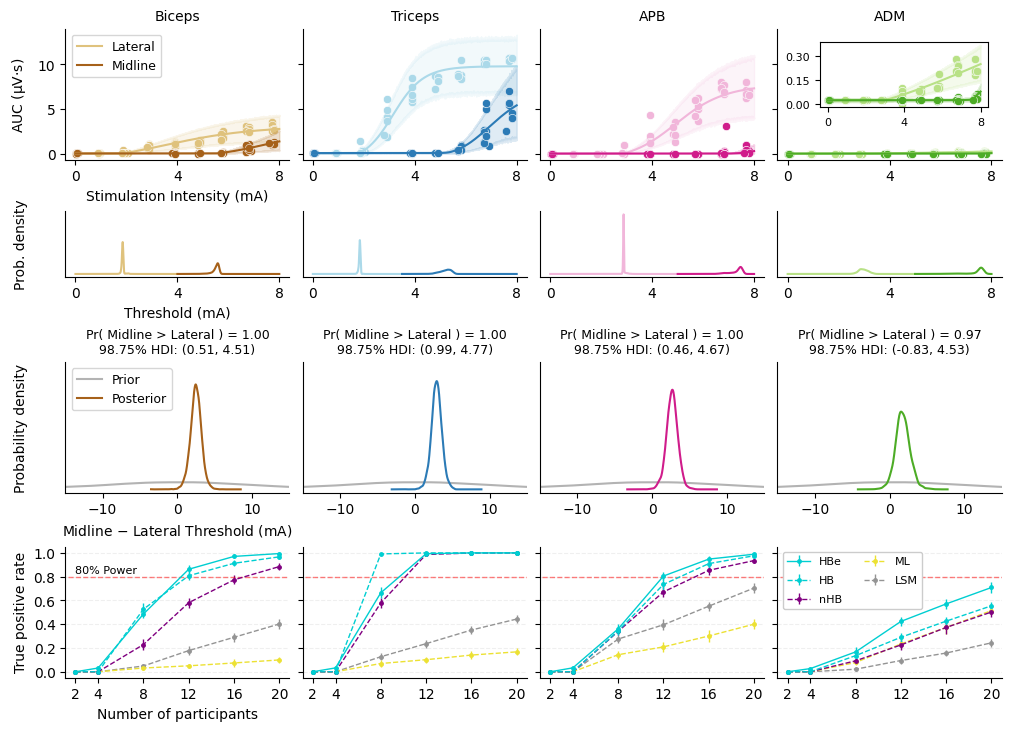

In [12]:
MODEL_NAMES_DICT = {
    HierarchicalBayesianModel.NAME: "Hierarchical Bayesian estimation (HBe)",
    DefaultHierarchicalBayesianModel.NAME: "Hierarchical Bayesian (HB)",
    NonHierarchicalBayesianModel.NAME: "Non-hierarchical Bayesian (nHB)",
    MaximumLikelihoodModel.NAME: "Maximum likelihood (ML)",
    LeastSquares.NAME: "Least squares method (LSM)"
}
MODEL_NAMES_DICT = {
    HierarchicalBayesianModel.NAME: "HBe",
    DefaultHierarchicalBayesianModel.NAME: "HB",
    NonHierarchicalBayesianModel.NAME: "nHB",
    MaximumLikelihoodModel.NAME: "ML",
    LeastSquares.NAME: "LSM"
}

alt_text_size = 9
response = model.response
n_response = model.n_response

# Plot
nrows, ncols = 4, n_response
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(2.5 * ncols, 1.8 * nrows),
    squeeze=False,
    height_ratios=[1, .5, 1, 1],
    constrained_layout=True,
)

for muscle_ind in range(model.n_response):
    for side in [0, 1]:
        c = (7, side)
        if side == 0: lab = "Lateral"
        if side == 1: lab = "Midline"
        color = response_colors[side][muscle_ind]

        ind = df[model.features].apply(tuple, axis=1).isin([c])
        temp_df = df[ind].reset_index(drop=True).copy()

        pred_ind = prediction_df[model.features].apply(tuple, axis=1).isin([c])
        temp_pred_df = prediction_df[pred_ind].reset_index(drop=True).copy()

        temp_obs = obs[:, pred_ind, muscle_ind]
        temp_mu = mu[:, pred_ind, muscle_ind]
        temp_obs_hpdi = obs_hpdi[:, pred_ind, muscle_ind]

        ax = axes[0, muscle_ind]
        sns.scatterplot(x=temp_df[model.intensity], y=temp_df[model.response[muscle_ind]], ax=ax, color=color)
        sns.lineplot(x=temp_pred_df[model.intensity], y=temp_mu.mean(axis=0), color=color, ax=ax, label=lab)
        ax.fill_between(
            temp_pred_df[model.intensity],
            temp_obs_hpdi[0, :],
            temp_obs_hpdi[1, :],
            color=color,
            alpha=.15
        )
        ax.sharex(axes[0, 0])
        ax.sharey(axes[0, 1])

        ax = axes[1, muscle_ind]
        x_grid = np.linspace(0, 8, 5000)
        if side == 0:
            match muscle_ind:
                case 0: x_grid_ind = x_grid < 4
                case 1: x_grid_ind = x_grid < 3.5
                case 2: x_grid_ind = x_grid < 5
                case 3: x_grid_ind = x_grid < 5

        if side == 1:
            match muscle_ind:
                case 0: x_grid_ind = x_grid > 4
                case 1: x_grid_ind = x_grid > 3.5
                case 2: x_grid_ind = x_grid > 5
                case 3: x_grid_ind = x_grid > 5

        x_grid = x_grid[x_grid_ind]
        kde = stats.gaussian_kde(a[:, *c, muscle_ind])
        density = kde(x_grid)
        ax.plot(x_grid, density, color=color)
        ax.sharex(axes[0, 0])
        ax.sharey(axes[1, 2])

    ax = axes[2, muscle_ind]
    samples = a_delta_loc[:, 0, muscle_ind]
    d = dist.Normal(0, 10)
    prior = d.sample(model.rng_key, (10000, ))
    sns.kdeplot(prior, ax=ax, color=prior_color, label="Prior")

    x_grid = np.linspace(samples.mean() - 6, samples.mean() + 6, 5000)
    kde = stats.gaussian_kde(samples)
    density = kde(x_grid)
    ax.plot(x_grid, density, color=response_colors[1][muscle_ind], label="Posterior")
    prob = (samples > 0).mean()
    ax.set_title(
        f"Pr( Midline > Lateral ) = {prob:.2f}\n{CORRECTED_LEVEL * 100:.2f}% HDI: ({hdi[muscle_ind, 0]:.2f}, {hdi[muscle_ind, 1]:.2f})",
        # fontweight="bold",
        size=alt_text_size
    )
    ax.sharex(axes[2, 0])
    ax.sharey(axes[2, 0])
    ax.set_xlim(left=-15, right=15)
    ax.set_ylim(bottom=-.02, top=.7)

    # Bootstrap
    ax = axes[3, muscle_ind]
    for model_ind, model_name in enumerate(model_names):
        x = n_subjects_space
        yme = arr.mean(axis=(0, 1))[model_ind, :, muscle_ind]
        yerr = TIMES_SEM * arr.mean(axis=1).std(axis=0, ddof=1)[model_ind, :, muscle_ind]
        ax.errorbar(
            x=n_subjects_space,
            y=yme,
            yerr=yerr,
            # marker="o",
            label=MODEL_NAMES_DICT[model_name],
            # linestyle=LINE_STYLE,
            ms=MARKER_SIZE,
            linewidth=LINE_WIDTH,
            # color=MODEL_COLORS[model_name]
            **MODEL_PLOT_KWARGS[model_name]
        )
        ax.sharex(axes[3, 1])
        ax.sharey(axes[3, 1])

muscle_ind = 3
ax = axes[0, muscle_ind]
ins = ax.inset_axes([0.19,0.4,0.75 ,0.5])
for side in [0, 1]:
    c = (7, side)
    color = response_colors[side][muscle_ind]

    ind = df[model.features].apply(tuple, axis=1).isin([c])
    temp_df = df[ind].reset_index(drop=True).copy()

    pred_ind = prediction_df[model.features].apply(tuple, axis=1).isin([c])
    temp_pred_df = prediction_df[pred_ind].reset_index(drop=True).copy()

    temp_obs = obs[:, pred_ind, muscle_ind]
    temp_mu = mu[:, pred_ind, muscle_ind]
    temp_obs_hpdi = obs_hpdi[:, pred_ind, muscle_ind]

    sns.scatterplot(x=temp_df[model.intensity], y=temp_df[model.response[muscle_ind]], ax=ins, color=color)
    sns.lineplot(x=temp_pred_df[model.intensity], y=temp_mu.mean(axis=0), color=color, ax=ins)
    ins.fill_between(
        temp_pred_df[model.intensity],
        temp_obs_hpdi[0, :],
        temp_obs_hpdi[1, :],
        color=color,
        alpha=.15
    )
    ins.set_xlabel("")
    ins.set_ylabel("")
    ins.set_xticks([0, 4, 8])
    # ins.set_yticks([0, 0.2])
    ins.yaxis.set_major_locator(plt.MaxNLocator(3))
    ins.tick_params(
        axis='both',
        which='both',
        left=True,
        bottom=True,
        right=False,
        top=False,
        labelleft=True,
        labelbottom=True,
        labelright=False,
        labeltop=False,
        labelrotation=ROTATION,
        labelsize=8
    )

for i in range(nrows):
    for j in range(ncols):
        ax = axes[i, j]
        sides = ['right', 'top']
        for side in sides:
            ax.spines[side].set_visible(False)
        ax.tick_params(
            axis='both',
            which='both',
            left=True,
            bottom=True,
            right=False,
            top=False,
            labelleft=False,
            labelbottom=True,
            labelright=False,
            labeltop=False,
            labelrotation=ROTATION
        )
        ax.set_xlabel("")
        ax.set_ylabel("")

ax = axes[0, 0]
ax.set_xlabel("Stimulation Intensity (mA)", size=axis_label_size)
ax.set_ylabel("AUC (µV$\cdot$s)", size=axis_label_size)
ax.tick_params(
    axis='both',
    which='both',
    labelleft=True,
    labelrotation=ROTATION
)
ax.set_yticks([0, 5, 10])
ax.set_xticks([0, 4, 8])
ax.legend(loc="upper left", prop={'size': alt_text_size})

ax = axes[1, 0]
ax.set_xlabel("Threshold (mA)", size=axis_label_size)
ax.set_ylabel("Prob. density", size=axis_label_size)

ax = axes[2, 0]
ax.set_xlabel("Midline $-$ Lateral Threshold (mA)", size=axis_label_size)
ax.set_ylabel("Probability density", size=axis_label_size)
ax.legend(loc="upper left", prop={'size': alt_text_size})

ax = axes[3, 0]
ax.set_xlabel("Number of participants", size=axis_label_size)
ax.set_ylabel("True positive rate", size=axis_label_size)
ax.set_xticks(n_subjects_space)
ax.set_yticks([0.2 * i for i in range(6)])
ax.tick_params(
    axis='both',
    which='both',
    labelleft=True,
)
ax.text(2, .81, "80% Power", va="bottom", ha="left", fontsize=axis_label_size - 2)
ax = axes[3, 3]
ax.legend(loc="upper left", fontsize=axis_label_size - 2, labelspacing=.8, reverse=True, ncol=2, framealpha=1)
for j in range(ncols):
    ax = axes[3, j]
    ax.axhline(
        y=.8,
		linestyle="--",
		color=RCOLOR,
		linewidth=LINE_WIDTH,
		alpha=LEVEL_ALPHA,
		xmin=0.01,
		xmax=1.
    )
    ax.grid(axis="y", linestyle=GRID_LINE_STYLE, alpha=GRID_ALPHA)

for j in range(1, model.n_response):
    ax = axes[0, j]
    ax.get_legend().remove()

for j in range(model.n_response):
    ax = axes[0, j]
    ax.set_title(
        response[j],
        # fontweight="bold",
        size=axis_label_size
    )
    ax = axes[1, j]
    ax.tick_params(
        axis='both',
        which='both',
        left=False,
    )
    ax = axes[2, j]
    ax.tick_params(
        axis='both',
        which='both',
        left=False,
    )

# fig.text(1, 0.3, "HDI: Highest Density Interval", size=alt_text_size, ha="right", va="bottom")
# fig.text(1, 0.01, "HDI: Highest Density Interval", size=alt_text_size, ha="right", va="bottom", fontweight="bold")
# fig.text(0.01, .4, "N = 13\nparticipants", size=alt_text_size - 2, fontweight="bold", rotation=15, ma="center")

fig.align_xlabels()
fig.align_ylabels()
# fig.align_ylabels(axes[0, :])
# fig.align_ylabels(axes[1:, :])

dest = os.path.join(BUILD_DIR, "use_cases_within.svg")
fig.savefig(dest, dpi=600)
dest = os.path.join(BUILD_DIR, "use_cases_within.png")
fig.savefig(dest, dpi=600)
logger.info(f"Saved figure to {dest}")
